<a href="https://colab.research.google.com/github/Jeronimocalles/analiticadenegocios/blob/main/Parcial1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Parcial 1

Una entidad del sector salud desea implementar un modelo analítico que permita clasificar pacientes según su probabilidad de padecer diabete a partir de variables médicas registradas en su historial clínico.

Para el desarrollo de este análisis se utiliza la base de datos Pima Indians Diabetes Database, la cual contiene información clínica de pacientes como número de embarazos, niveles de glucosa, presión arterial, índice de masa corporal, entre otras variables.

El objetivo del presente trabajo es aplicar y comparar tres modelos de clasificación utilizados en analítica de datos:

*   Naive Bayes
*   Árboles de Decisión
*   Clustering K-Means

El desempeño de los modelos será evaluado mediante la matriz de confusión y métricas derivadas, con el fin de determinar cuál modelo ofrece un mejor desempeño para apoyar la toma de decisiones en la detección de diabetes.

#0. Se procede con la carga de librerías

In [ ]:
# Librerías principales
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Librerías específicas
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.cluster import KMeans
from sklearn.metrics import confusion_matrix

import warnings
warnings.filterwarnings('ignore')

#1. Análisis Base de datos

In [ ]:
#Descargar la base de datos
import kagglehub

# Download latest version
path = kagglehub.dataset_download("uciml/pima-indians-diabetes-database")

print("Path to dataset files:", path)

XDB = pd.read_csv(path + "/diabetes.csv")
# Número de observaciones y variables
print("Número de observaciones:", XDB.shape[0])
print("Número de variables:", XDB.shape[1])

# Tipos de datos
print(XDB.dtypes)

# Estadísticas descriptivas
XDB.describe()

Using Colab cache for faster access to the 'pima-indians-diabetes-database' dataset.
Path to dataset files: /kaggle/input/pima-indians-diabetes-database
Número de observaciones: 768
Número de variables: 9
Pregnancies                   int64
Glucose                       int64
BloodPressure                 int64
SkinThickness                 int64
Insulin                       int64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64
dtype: object


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


# *Analisis de la base de datos*
La base de datos analizada esta compuesta por 768 observaciones y 9 variables, donde 8 corresponden a variables de entrada (relacionadas con características médicas del paciente) y una variable de salida denominada Outcome, la cual indica si el paciente presenta diabetes (1) o no (0).

Las 8 variables de entrada son:

1.   *Pregnancies:* número de embarazos que ha tenido el paciente a la hora de la evaluación.
2. *Glucose:* nivel de glucosa en sangre del paciente en el momento de la evaluación.
3. *BloodPressure:* presión arterial al momento de la evaluación.
4. *SkinThickness:* grosor del pliegue cutáneo del paciente cuando se ha evaluado el paciente
5. *Insulin:* nivel de insulina en la sangre del paciente en el momento de la evaluación.
6. *BMI:* índice de masa corporal del paciente cuando se realizó la evaluación.
7. *DiabetesPedigreeFunction:* factor hereditario de diabetes del paciente.
8. *Age:* edad del paciente en el momento de la evaluación

La variable de salida es:
1. *Outcome:* variable que indica si el paciente presenta diabetes 1 o si no la presenta 0.

A partir de las estadísticas descriptivas se puede observar que algunas variables presentan una alta dispersión en sus valores, particularmente Glucose, Insulin y BMI, lo cual puede ser indicativo de diferentes perfiles de pacientes dentro de la base de datos.

#2. Análisis de correlación de los datos

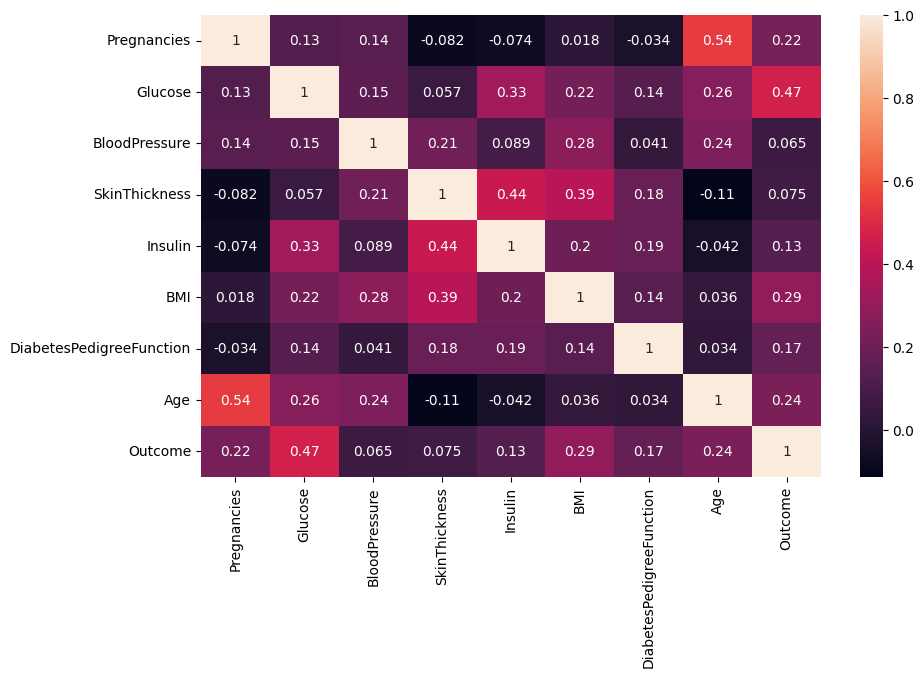

In [ ]:
plt.figure(figsize=(10,6))
sns.heatmap(XDB.corr(), annot=True)
plt.show()

#*Análisis de correlación de datos*
De acuerdo con el análisis de correlación presentado en el heatmap, se pueden identificar algunas relaciones relevantes entre las variables del modelo.

La variable que presenta mayor correlación con la variable de salida Outcome es Glucose, con un valor de 0.47, lo cual indica una relación positiva moderada. Este resultado es consistente desde el punto de vista médico, ya que niveles elevados de glucosa en sangre suelen estar directamente asociados con la presencia de diabetes.

También se observa una correlación entre BMI y Outcome de 0.29, lo que indica que pacientes con mayores índices de masa corporal tienden a presentar una mayor probabilidad de padecer diabetes. Aunque esta correlación no es muy alta, sí muestra una relación positiva relevante para el modelo.

Otra relación destacable se presenta entre Age y Pregnancies, con una correlación de 0.54, siendo esta una de las correlaciones más altas dentro de las variables de entrada. Este resultado es lógico, ya que a mayor edad es posible que el número de embarazos también sea mayor.

Adicionalmente, se observa una correlación moderada entre SkinThickness e Insulin de 0.44, lo cual puede indicar que pacientes con mayor grosor del pliegue cutáneo presentan niveles de insulina más elevados.

En términos generales, el análisis de correlación permite identificar que las variables Glucose (0.47), BMI (0.29) y Age (0.24) poseen una mayor relación con la variable de salida Outcome, lo cual sugiere que estas variables pueden tener una mayor influencia en la clasificación de pacientes con diabetes dentro de los modelos analíticos que se implementarán posteriormente.

# 3. Implementación Modelo Naive Bayes

In [ ]:
XD = XDB.iloc[:,0:8]
yd = XDB.iloc[:,8]

mnb = GaussianNB()
mnb.fit(XD,yd)

# Medias y desviaciones
u = mnb.theta_
sigma = np.sqrt(mnb.var_)

print("Medias:")
print(u)

print("Desviaciones:")
print(sigma)

Medias:
[[  3.298      109.98        68.184       19.664       68.792
   30.3042       0.429734    31.19      ]
 [  4.86567164 141.25746269  70.82462687  22.1641791  100.3358209
   35.14253731   0.5505      37.06716418]]
Desviaciones:
[[  3.01416809  26.11504573  18.04500366  14.87505016  98.76637459
    7.68216217   0.29880826  11.65598187]
 [  3.73425437  31.87997773  21.45167782  17.64669641 138.43013459
    7.24940518   0.37167699  10.94777197]]


*Evaluación del modelo a través de la matriz de confusión*

In [ ]:
#Matriz de confusión
ydp = mnb.predict(XD)

cm = confusion_matrix(yd,ydp)
print(cm)

#Se determinan las metricas de la matriz de confusión
VN = cm[0,0]
FP = cm[0,1]
FN = cm[1,0]
VP = cm[1,1]


#1. Exactitud: Funcionamiento general del modelo
Exactitud = (VP+VN)/(VP+VN+FP+FN)
print("Exactitud:",Exactitud)

#2. Tasa de error: % fallos del modelo
TasaError = (FP+FN)/(VP+VN+FP+FN)
print("Tasa Error:",TasaError)

#3. Sensibilidad del modelo: como se comporto con respecto a los positivos
Sensibilidad = VP/(VP+FN)
print("Sensibilidad:",Sensibilidad)

#4. Especificidad: como se comporta pronosticando negativos
Especificidad = VN/(VN+FP)
print("Especificidad:",Especificidad)

#5. Precisión: es una versión de como se comporta el modelo frente a los positivos solamente
Precision = VP/(VP+FP)
print("Precision:",Precision)

#6. Predicción Negativa: como funciona el modelo pronosticando negativos
PrediccionNegativa = VN/(VN+FN)
print("Predicción Negativa:",PrediccionNegativa)

[[421  79]
 [103 165]]
Exactitud: 0.7630208333333334
Tasa Error: 0.23697916666666666
Sensibilidad: 0.6156716417910447
Especificidad: 0.842
Precision: 0.6762295081967213
Predicción Negativa: 0.8034351145038168


#*Análisis de resultados Naive Bayes*
De acuerdo con la matriz de confusión obtenida del modelo Naive Bayes, el modelo alcanzó una exactitud de 76.30%, lo que indica que aproximadamente 3 de cada 4 pacientes fueron clasificados correctamente por el modelo, y demuestra el buen comportamiento del modelo frente a la clasificación de los pacientes diabéticos. Por otro lado, la tasa de error fue de 23.69%, lo que representa el porcentaje de clasificaciones incorrectas realizadas por el modelo.

Con respecto a la sensibilidad (61.57%), esta métrica indica la capacidad del modelo para identificar correctamente a los pacientes que realmente tienen diabetes. En este caso, el modelo logra detectar aproximadamente 6 de cada 10 pacientes diabéticos, lo cual sugiere que todavía existen algunos casos positivos que el modelo no logra identificar adecuadamente.

Por otro lado, la especificidad del modelo es de 84.2%, lo que indica que el modelo tiene una alta capacidad para identificar correctamente a los pacientes que no presentan diabetes. En otras palabras, el modelo es bastante eficiente clasificando los casos negativos.

La precisión del modelo es de 67.62%, lo que significa que, de todos los pacientes que el modelo clasificó como diabéticos, aproximadamente 2 de cada 3 realmente tienen la enfermedad.

Finalmente, la predicción negativa es de 80.34%, lo que indica que cuando el modelo clasifica a un paciente como no diabético, existe una probabilidad cercana al 80% de que dicha clasificación sea correcta.

En términos generales, el modelo Naive Bayes presenta un buen desempeño en la identificación de pacientes sin diabetes, evidenciado por su alta especificidad, aunque su capacidad para detectar todos los casos positivos es moderada, como se observa en el valor de la sensibilidad.

#4. Implementación Modelo Árboles de Decisión

In [ ]:
mar = DecisionTreeClassifier(criterion='gini',max_depth=4)

mar.fit(XD,yd)

ydp = mar.predict(XD)

cm = confusion_matrix(yd,ydp)

print(cm)

#Métricas Arboles de desempeño usando mátriz de confusión
VN = cm[0,0]
FP = cm[0,1]
FN = cm[1,0]
VP = cm[1,1]

#1. Exactitud: Funcionamiento general del modelo
Exactitud = (VP+VN)/(VP+VN+FP+FN)
print("Exactitud:",Exactitud)

#2. Tasa de error: % fallos del modelo
TasaError = (FP+FN)/(VP+VN+FP+FN)
print("Tasa Error:",TasaError)

#3. Sensibilidad del modelo: como se comporto con respecto a los positivos
Sensibilidad = VP/(VP+FN)
print("Sensibilidad:",Sensibilidad)

#4. Especificidad: como se comporta pronosticando negativos
Especificidad = VN/(VN+FP)
print("Especificidad:",Especificidad)

#5. Precisión: es una versión de como se comporta el modelo frente a los positivos solamente
Precision = VP/(VP+FP)
print("Precision:",Precision)

#6. Predicción Negativa: como funciona el modelo pronosticando negativos
PrediccionNegativa = VN/(VN+FN)
print("Predicción Negativa:",PrediccionNegativa)



#Grafica Arbol de decisión
from sklearn.tree import export_graphviz
from pydotplus import graph_from_dot_data

vs = XDB.columns[0:8]

dot_data = export_graphviz(mar, feature_names=vs)
graph = graph_from_dot_data(dot_data)
graph.write_png('ArbolDiabetes.png')

[[459  41]
 [119 149]]
Exactitud: 0.7916666666666666
Tasa Error: 0.20833333333333334
Sensibilidad: 0.5559701492537313
Especificidad: 0.918
Precision: 0.7842105263157895
Predicción Negativa: 0.7941176470588235


True

#*Análisis de resultados Árbol de Decisión*

En términos generales, el modelo alcanzó una exactitud de 79.17%, y demuestra el buen desempeño del modelo, ya que es superior a 75%. Por otro lado, la tasa de error fue de 20.83%, lo que representa el porcentaje de clasificaciones incorrectas realizadas por el modelo.

Con respecto a la sensibilidad, esta métrica indica la capacidad del modelo para identificar correctamente a los pacientes que realmente presentan diabetes. En este caso, el modelo logra detectar 55.60%, lo cual sugiere que aún existen algunos casos positivos que el modelo no logra identificar adecuadamente.

Por otro lado, la especificidad del modelo es de 91.8%, lo que indica que el modelo posee una alta capacidad para identificar correctamente a los pacientes que no presentan diabetes, siendo esta una de las métricas más altas del modelo.

La precisión del modelo, que significa que, de todos los pacientes que el modelo clasificó como diabéticos el 78.42% realmente presentan la enfermedad.

Finalmente, la predicción negativa es de 79.41%, lo que indica que cuando el modelo clasifica a un paciente como no diabético, existe una probabilidad cercana al 79% de que dicha clasificación sea correcta.

Desde el punto de vista estructural del árbol de decisión, se puede observar que la variable Glucose es la primera variable utilizada para dividir los datos, específicamente con la regla Glucose ≤ 127.5, lo cual confirma que el nivel de glucosa es una de las variables más determinantes en la clasificación de pacientes con diabetes.

A partir de esta división inicial, el árbol utiliza variables adicionales como BMI, Age e Insulin para generar reglas de clasificación más específicas que permiten separar los pacientes en diferentes perfiles de riesgo.

Uno de los nodos puros del árbol se puede observar en el nodo donde BMI ≤ 9.65, el cual posee 41 observaciones con una distribución (39/2), lo que indica que prácticamente todos los pacientes en este nodo pertenecen a la misma categoría de clasificación. Esto demuestra que bajo ciertas condiciones específicas el modelo puede identificar con alta certeza la presencia o ausencia de diabetes.

En términos generales, el modelo de árbol de decisión presenta un desempeño ligeramente superior al modelo Naive Bayes en términos de exactitud, además de ofrecer una ventaja importante en la interpretabilidad, ya que permite identificar reglas de decisión claras que pueden ser utilizadas para comprender mejor los factores que influyen en la presencia de diabetes en los pacientes.

#5. Implementación Modelo K-Means

In [ ]:
np.random.seed(42)

NC = 5
mkm = KMeans(n_clusters=NC, random_state=42)

mkm.fit(XD)

#Obtenemos las características de cada grupo
Tabla = pd.DataFrame(mkm.cluster_centers_, columns=XD.columns)

display(Tabla)

#Para saber los porcentajes de Diabetes o No por característica
ydp = mkm.labels_

XDB2 = XDB.copy()
XDB2['Cluster'] = ydp

NApr = XDB2.groupby('Cluster').agg({"Outcome":lambda x: (x==1).sum()})
NPrn = XDB2.groupby('Cluster').agg({"Outcome":lambda x: (x==0).sum()})

NApr2 = NApr/(NApr+NPrn)
NPrn2 = NPrn/(NApr+NPrn)

df2 = pd.DataFrame(np.column_stack((NApr2,NPrn2)),
                   columns=['Prob_Diabetes','Prob_No_Diabetes'])

display(df2)



,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,4.250000,149.615385,74.038462,30.865385,291.480769,35.575000,0.558635,33.903846
1,4.403646,119.096354,67.372396,11.932292,0.562500,30.954167,0.422201,35.583333
2,2.638418,101.954802,68.841808,26.853107,77.841808,31.096610,0.469458,27.836158
3,3.111111,165.833333,73.444444,35.666667,548.833333,36.961111,0.660667,34.555556
4,3.781022,133.598540,71.861314,30.583942,162.452555,34.048175,0.556504,33.233577


,Prob_Diabetes,Prob_No_Diabetes
0,0.500000,0.500000
1,0.364583,0.635417
2,0.129944,0.870056
3,0.666667,0.333333
4,0.489051,0.510949


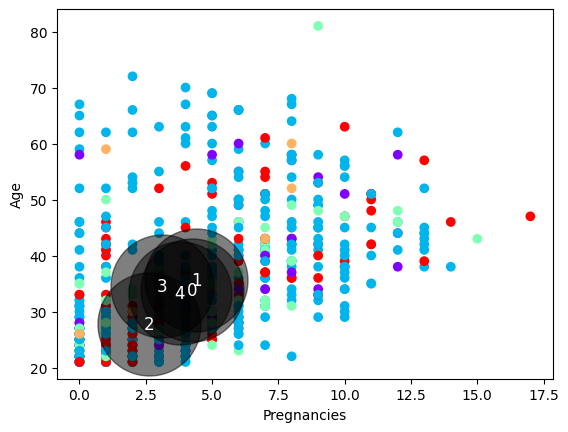

In [ ]:
# Gráfica de los clusters utilizando las variables con mayor correlación

centers = mkm.cluster_centers_   #Centroides o perfiles

preg = np.array(XD.iloc[:,0])   #Pregnancies
age = np.array(XD.iloc[:,7])    #Age

plt.figure()

plt.scatter(preg, age, c=mkm.labels_, cmap='rainbow')
plt.scatter(centers[:,0], centers[:,7], c='black', s=5500, alpha=0.5)

plt.xlabel("Pregnancies")
plt.ylabel("Age")

# Añadir número del cluster en los centros
for i, center in enumerate(centers):
    plt.text(center[0], center[7], str(i), color='white', fontsize=12, ha='center', va='center')

plt.show()

#*Analisis de resultados K-Means*
A partir de los resultados obtenidos para cada cluster, se pueden identificar distintos perfiles de pacientes. Por ejemplo, el cluster 3 presenta el promedio de glucosa más alto (165.83), acompañado de un BMI promedio de 36.96 y un nivel de insulina promedio de 548.83, lo cual sugiere que este grupo agrupa pacientes con características clínicas asociadas a un mayor riesgo de diabetes.

Por otro lado, el cluster 2 presenta valores promedio más bajos en varias de las variables médicas relevantes, particularmente en glucosa (101.95) y edad promedio (27.84), lo cual podría indicar un grupo de pacientes con menor riesgo relativo frente a la enfermedad.

Al analizar la probabilidad de diabetes dentro de cada cluster, se observan diferencias importantes entre los grupos:

Cluster 3: Probabilidad de diabetes 0.67 (66.67%), siendo el grupo con mayor probabilidad de presentar la enfermedad.

Cluster 0: Probabilidad de diabetes 0.50 (50%), mostrando un grupo con riesgo intermedio.

Cluster 4: Probabilidad de diabetes 0.49 (48.9%), también cercano a un riesgo intermedio.

Cluster 1: Probabilidad de diabetes 0.36 (36.46%), lo que indica un grupo con menor presencia de la enfermedad.

Cluster 2: Probabilidad de diabetes 0.13 (12.99%), siendo el grupo con menor probabilidad de diabetes dentro del modelo.

Estos resultados permiten identificar claramente diferentes perfiles de riesgo entre los pacientes, donde algunos clusters agrupan individuos con características metabólicas más asociadas a la presencia de diabetes.

#6. Evaluar el paciente solicitado


In [ ]:
XDp=[2,85,65,29,94,39.6,0.93,27]

*Naive Bayes*

In [ ]:
XDp=[2,85,65,29,94,39.6,0.93,27]

ydc = mnb.predict([XDp])

print(ydc)

[0]


*Arbol de Decisión*

In [ ]:
ydc = mar.predict([XDp])
print(ydc)

[0]


*K-Means*

In [ ]:
cluster = mkm.predict(np.array(XDp).reshape(1,-1))

print("Cluster:",cluster)

print("Probabilidad diabetes:", NApr2.iloc[cluster[0]])

Cluster: [2]
Probabilidad diabetes: Outcome    0.129944
Name: 2, dtype: float64


#7. Conclusión
A partir de los resultados obtenidos en los tres modelos implementados (Naive Bayes, Árbol de Decisión y K-Means), es posible realizar una comparación de su desempeño con el fin de identificar cuál modelo resulta más adecuado para la clasificación de pacientes con diabetes.

En primer lugar, el modelo Naive Bayes presentó una exactitud de 76.30%, con una sensibilidad de 61.57% y una especificidad de 84.2%. Estos resultados indican que el modelo posee una buena capacidad para identificar pacientes que no presentan diabetes, aunque su capacidad para detectar todos los pacientes diabéticos es moderada. A pesar de esto, el modelo presenta la ventaja de ser computacionalmente simple y eficiente.

Por otro lado, el modelo de Árbol de Decisión presentó un desempeño ligeramente superior, alcanzando una exactitud de 79.17%, con una especificidad de 91.8% y una precisión de 78.42%. Esto indica que el modelo tiene una alta capacidad para clasificar correctamente a los pacientes que no presentan diabetes y una buena confiabilidad cuando predice que un paciente tiene la enfermedad. Adicionalmente, una de las principales ventajas de este modelo es su interpretabilidad, ya que permite identificar reglas de decisión claras basadas en variables clínicas como Glucose, BMI, Age e Insulin, lo cual facilita la comprensión del modelo por parte de profesionales del sector salud.

Finalmente, el modelo de K-Means permitió segmentar a los pacientes en cinco grupos con diferentes niveles de riesgo de diabetes. Por ejemplo, el cluster 3 presentó una probabilidad de diabetes de 66.67%, mientras que el cluster 2 presentó solo un 12.99%, lo que evidencia la existencia de diferentes perfiles clínicos dentro de la población analizada. Sin embargo, al tratarse de un modelo no supervisado, su función principal es la segmentación de pacientes y no la predicción directa de la enfermedad.

Teniendo en cuenta las métricas obtenidas y los criterios de interpretación del modelo, se recomienda utilizar el modelo de Árbol de Decisión para este problema. Esto se debe a que presenta la mayor exactitud entre los modelos supervisados analizados, una alta especificidad, y además permite generar reglas de decisión fácilmente interpretables, lo cual resulta especialmente importante en el sector salud, donde la comprensión del modelo y la transparencia en la toma de decisiones son factores clave para su implementación en contextos clínicos.

En conclusión, el modelo de Árbol de Decisión ofrece el mejor equilibrio entre desempeño predictivo e interpretabilidad, lo que lo convierte en la alternativa más adecuada para apoyar la clasificación de pacientes con diabetes en este caso de estudio.